# Objective of Project :

This system is a kind of an
information filtering system which seeks to predict the &quot;rating&quot; or preferences which user is
interested in.

# Agenda of our project :

1. Import Libraries
2. Load Dataset
3. Data Exploration
4. Data Cleaning
5. Data Reduction
6. Feature Engineering
7. User Clustering
8. Clustering Comparison
9. Item-Item Collaborative Filtering
10. Similar User Recommendation
11. Product Recommendation
12. Explainable Recommendation Function
13. Evaluation
14. Save Models
15. Streamlit Deployment Code

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix

from sklearn.decomposition import TruncatedSVD

from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

from sklearn.metrics.pairwise import cosine_similarity

import pickle

# 2.Load Dataset

In [2]:
df = pd.read_csv("C:/Users/shanm/Python_Practice/P674/ratings.csv")
df.head(2)

,AKM1MP6P0OYPR,0132793040,5.0,1365811200
0,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
1,A2NWSAGRHCP8N5,0439886341,1.0,1367193600


# 3.Data Exploration

In [3]:
df.shape

(7824481, 4)

In [4]:
df.columns = ['userId', 'productId', 'rating', 'timestamp']

In [5]:
df.tail(1)

,userId,productId,rating,timestamp
7824480,A2G81TMIOIDEQQ,BT008V9J9U,5.0,1312675200


# 4.Data Cleaning

a.Drop Timestamp - Meaningless


In [6]:
df = df.drop("timestamp", axis=1)
df.head(1)

,userId,productId,rating
0,A2CX7LUOHB2NDG,0321732944,5.0


b.Check for null values


In [7]:
print(df.isnull().sum())

userId       0
productId    0
rating       0
dtype: int64


c.Drop Duplicates 


In [8]:
df.drop_duplicates(inplace=True)

d.Check for Data Types


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824481 entries, 0 to 7824480
Data columns (total 3 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     object 
 1   productId  object 
 2   rating     float64
dtypes: float64(1), object(2)
memory usage: 179.1+ MB


e. Statistical summary


In [10]:
df.describe()

,rating
count,7.824481e+06
mean,4.012337e+00
std,1.380910e+00
min,1.000000e+00
25%,3.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


f.Dataset statistics


In [11]:
print("Total Ratings:",len(df))

print("Unique ratings :" ,df['rating'].nunique())

print("Unique Users:",
      df['userId'].nunique())

print("Unique Products:",
      df['productId'].nunique())

Total Ratings: 7824481
Unique ratings : 5
Unique Users: 4201696
Unique Products: 476001


g.Data Visualization


Countplot - To visualize Ratings

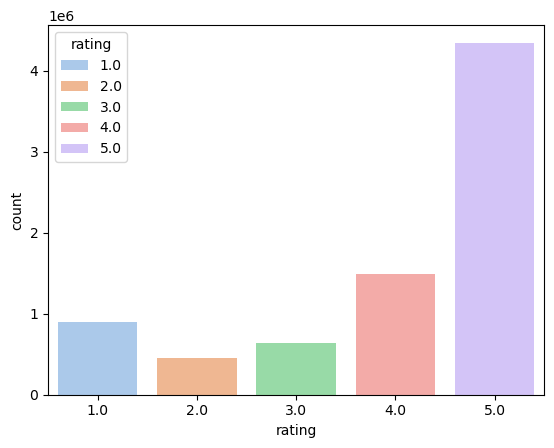

In [12]:
sns.countplot(x='rating', data=df , hue='rating',palette='pastel')
plt.show()

Finding top rated products 

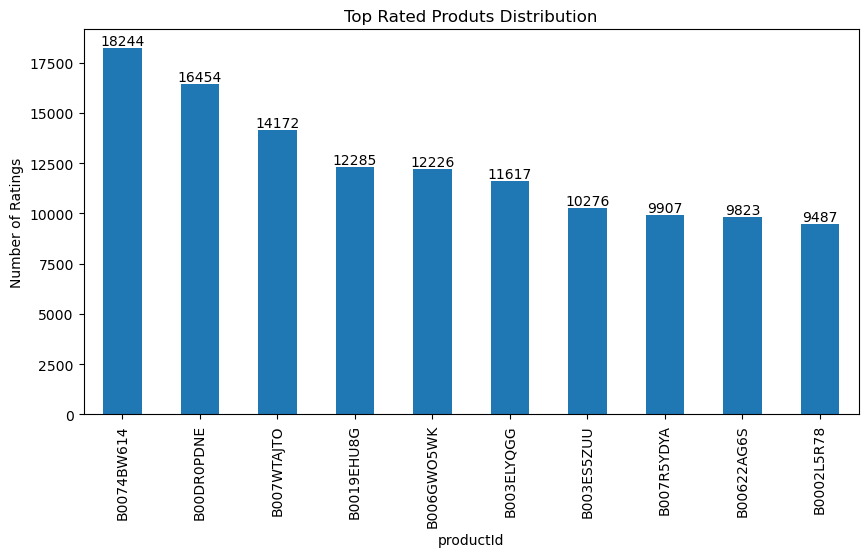

In [13]:
top_products = df['productId'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.title("Top Rated Produts Distribution")
ax = top_products.plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.ylabel('Number of Ratings')
plt.show()

Find Active users

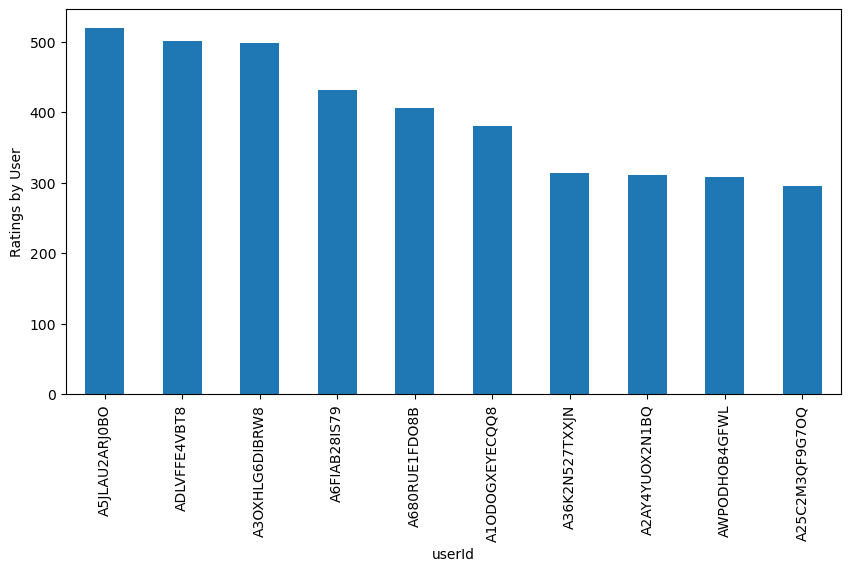

In [14]:
active_users = df['userId'].value_counts().head(10)

plt.figure(figsize=(10,5))
active_users.plot(kind="bar")
plt.ylabel('Ratings by User')
plt.show()


# 5. Data Reduction


Lets Keep only:

- Users with ≥ 50 ratings
- Products with ≥ 10 ratings

In [15]:
user_counts = df.userId.value_counts()
active_users = user_counts[user_counts >= 50].index

df = df[df.userId.isin(active_users)]

In [16]:
product_counts = df.productId.value_counts()

popular_products = product_counts[product_counts >= 20].index

df = df[df.productId.isin(popular_products)]

Check new shape


In [17]:
print(df.shape)

(21168, 3)


# 6.Feature Engineering

Creating an user-item matrix

In [18]:
user_item = pd.pivot_table(
    df,
    index='userId',
    columns='productId',
    values='rating',
    fill_value=0
)
user_item.head(2)

productId,B00004SB92,B00004ZCJE,B00005LEN4,B00005T3G0,B000067RT6,B00006B7DA,B00006I53S,B00006JN3G,B00006RVPW,B00007E7JU,...,B00I3YKEKG,B00IL7B2YM,B00IORDBPC,B00IVFDZBC,B00IX2VGFA,B00JC5Y6WM,B00JC5Y6YA,B00JF0D7RE,B00JP12170,B00K91DB7Y
userId,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Convert to sparse matrix


In [19]:
sparse_matrix = csr_matrix(user_item.values)

Dimensionality Reduction


In [20]:
svd = TruncatedSVD(
    n_components=50,
    random_state=42)

user_features = svd.fit_transform(sparse_matrix)

print(user_features.shape)

(1512, 50)


# 7.User Clustering

<b><u>a). KMeans</b></u>

In [21]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

k_labels = kmeans.fit_predict(user_features)

k_sil = silhouette_score(user_features, k_labels)

k_db = davies_bouldin_score(user_features,k_labels)


Finding best k value for clusters

In [22]:
inertia = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(user_features)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(user_features, kmeans.labels_))

Elbow Method to find best k


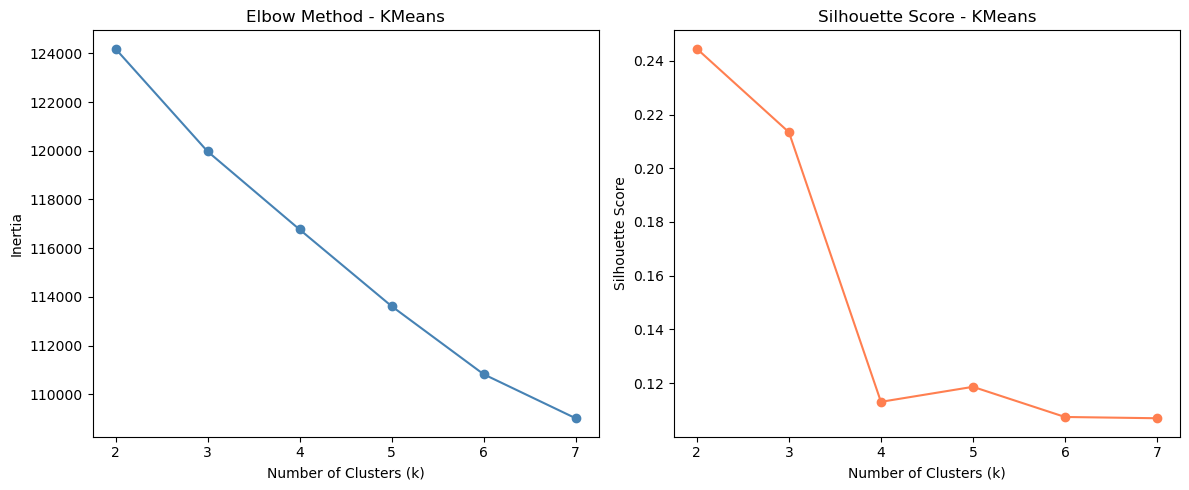


Silhouette Scores: [0.24448859165892153, 0.21342004168840006, 0.11299689481629217, 0.11858848842538151, 0.1073572689658249, 0.10688313915794724]
Best k: 2


In [23]:
# Plot Elbow Method
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method - KMeans')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='coral')
plt.title('Silhouette Score - KMeans')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:", silhouette_scores)
print("Best k:", k_range[silhouette_scores.index(max(silhouette_scores))])

Applying best k =2 



In [24]:
kmeans_best = KMeans(
    n_clusters=5,
    random_state=42
)

k_labels_best = kmeans.fit_predict(user_features)

k_sil_best = silhouette_score(user_features, k_labels)

k_db_best = davies_bouldin_score(user_features,k_labels)


<b><u>b). MiniBatchKMeans</b></u>

In [25]:
mbk = MiniBatchKMeans(
    n_clusters=5,
    batch_size=1000,
    random_state=42
)

mbk_labels = mbk.fit_predict(user_features)

mbk_sil = silhouette_score(user_features,mbk_labels)

mbk_db = davies_bouldin_score(user_features,mbk_labels)


<b><u>c). Agglomerative</b></u>

In [26]:
agg = AgglomerativeClustering(
    n_clusters=5)

agg_labels = agg.fit_predict(user_features )

agg_sil = silhouette_score(user_features,agg_labels)

agg_db = davies_bouldin_score(user_features,agg_labels)


<b><u>d). DBSCAN</b></u>

In [27]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5)

db_labels = dbscan.fit_predict(
    user_features)



#### Remove noise in DBSCAN
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"\nNumber of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

if n_clusters > 1:
    mask = db_labels != -1
    db_sil = silhouette_score(user_features[mask], db_labels[mask])
    print(f"DBSCAN Silhouette Score: {db_sil:.4f}")
else:
    db_sil = 0
    print("DBSCAN found only 1 cluster - cannot calculate silhouette score")




Number of clusters: 1
Number of noise points: 1502
DBSCAN found only 1 cluster - cannot calculate silhouette score


# 8.Clustering Comparison

In [28]:
comparison = pd.DataFrame({

    "Model":["KMeans", "MiniBatchKMeans", "Agglomerative","DBSCAN"],

    "Silhouette":[k_sil, mbk_sil,agg_sil,db_sil],

    "Davies_Bouldin":[k_db, mbk_db, agg_db,'N/A'],

    'Suitable for Data': ['Good', 'Moderate', 'Moderate','Poor']
})

comparison

,Model,Silhouette,Davies_Bouldin,Suitable for Data
0,KMeans,0.189007,3.355479,Good
1,MiniBatchKMeans,0.121825,4.013458,Moderate
2,Agglomerative,0.059101,3.271222,Moderate
3,DBSCAN,0.000000,N/A,Poor


KMeans model serves the best

Train Final Clustering Model

In [29]:
final_cluster_model = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = final_cluster_model.fit_predict(
    user_features
)

In [30]:
cluster_df = pd.DataFrame({

    'userId':user_item.index,

    'cluster':clusters
})
cluster_df.head()


,userId,cluster
0,A100UD67AHFODS,4
1,A100WO06OQR8BQ,2
2,A105S56ODHGJEK,1
3,A105TOJ6LTVMBG,4
4,A10AFVU66A79Y1,2


# 9.Item-Item Collaborative Filtering

Build Item Similarity Matrix

In [31]:
item_matrix = pd.pivot_table(
    df,
    index='productId',
    columns='userId',
    values='rating',
    fill_value=0
)

In [32]:
item_similarity = cosine_similarity(item_matrix)
item_similarity

array([[1.        , 0.04574776, 0.08252395, ..., 0.        , 0.06655141,
        0.        ],
       [0.04574776, 1.        , 0.10415475, ..., 0.04328465, 0.04724751,
        0.03932177],
       [0.08252395, 0.10415475, 1.        , ..., 0.        , 0.02599587,
        0.        ],
       ...,
       [0.        , 0.04328465, 0.        , ..., 1.        , 0.03762734,
        0.        ],
       [0.06655141, 0.04724751, 0.02599587, ..., 0.03762734, 1.        ,
        0.11887544],
       [0.        , 0.03932177, 0.        , ..., 0.        , 0.11887544,
        1.        ]])

In [33]:
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_matrix.index,
    columns=item_matrix.index
)
item_similarity_df.head(2)

productId,B00004SB92,B00004ZCJE,B00005LEN4,B00005T3G0,B000067RT6,B00006B7DA,B00006I53S,B00006JN3G,B00006RVPW,B00007E7JU,...,B00I3YKEKG,B00IL7B2YM,B00IORDBPC,B00IVFDZBC,B00IX2VGFA,B00JC5Y6WM,B00JC5Y6YA,B00JF0D7RE,B00JP12170,B00K91DB7Y
productId,,,,,,,,,,,,,,,,,,,,,
B00004SB92,1.000000,0.045748,0.082524,0.000000,0.0,0.087840,0.000000,0.038698,0.000000,0.000000,...,0.00000,0.043466,0.051071,0.00000,0.089157,0.0,0.037781,0.000000,0.066551,0.000000
B00004ZCJE,0.045748,1.000000,0.104155,0.106912,0.0,0.020009,0.059308,0.123900,0.051203,0.172307,...,0.01474,0.083498,0.000000,0.02466,0.038612,0.0,0.032870,0.043285,0.047248,0.039322


# 10.Similar User Recommendation

In [34]:
user_similarity = cosine_similarity(user_features)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item.index,
    columns=user_item.index
)

In [35]:
def get_similar_users(user_id,top_n=10):

    users = user_similarity_df[user_id].sort_values(ascending=False)
    return users.iloc[1:top_n+1]

# 12. Product Recommendation Function

In [36]:
def recommend_products(product_id,top_n=10):

    recommendations = item_similarity_df[product_id].sort_values(ascending=False)
    return recommendations.iloc[1:top_n+1]

# 13. Explainable Recommendation

In [37]:
def explainable_recommendation(user_id,product_id):

    cluster_no = cluster_df[cluster_df.userId ==user_id]['cluster'].values[0]

    similar_users = get_similar_users(user_id)

    products = recommend_products(product_id)

    print("\n===== Recommendation Report =====" )

    print("Clustering Method Used : KMeans")

    print("Cluster Assigned :",cluster_no)

    print("\nSimilar Users")

    print(similar_users)

    print("\nRecommended Products")

    print(products)

# 13. Evaluation

In [38]:
explainable_recommendation(user_id='A100UD67AHFODS',product_id='B00004SB92')


===== Recommendation Report =====
Clustering Method Used : KMeans
Cluster Assigned : 4

Similar Users
userId
A328S9RN3U5M68    0.664349
A33XMCG1UFDSY2    0.614414
A35A2RWUMC737N    0.604089
A2D1LPEUCTNT8X    0.600810
APBB297H3ZA5E     0.587765
A3V5F050GVZ56Q    0.558101
A9DYWY9VOSP1P     0.554987
AZMY6E8B52L2T     0.553859
A3HPCRD9RX351S    0.547542
AN9WA4C5E7YY5     0.545114
Name: A100UD67AHFODS, dtype: float64

Recommended Products
productId
B00B588HY2    0.122634
B000M17AVO    0.122625
B000UY1MB2    0.110686
B00007KDVI    0.108338
B001L6LG5K    0.107172
B00ATM1MHO    0.106008
B000TG4BA0    0.104535
B00FJRS5BA    0.100998
B0021Y73W6    0.099812
B005KFONIU    0.099515
Name: B00004SB92, dtype: float64


# 14. Save Models

In [39]:
pickle.dump(final_cluster_model,open("cluster_model.pkl","wb"))

pickle.dump(item_similarity_df,open("item_similarity.pkl","wb"))

pickle.dump(cluster_df,open("cluster_df.pkl","wb"))

pickle.dump(user_similarity_df,open("user_similarity.pkl","wb"))

pickle.dump(user_item,open("user_item.pkl","wb"))